In [3]:
# Setup and Imports
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.append(Path.cwd().parent.parent.as_posix())
from demo_and_analysis.plots.utils.wandb_utils import get_wandb_stats

# Configure matplotlib for publication quality
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 11
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["xtick.major.width"] = 1.2
plt.rcParams["ytick.major.width"] = 1.2
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.2

In [5]:
# Benchmark / run configuration
# Run IDs to load for each benchmark and mode.
run_ids = {
    # "tpch": {"st": "...", "mt": "..."},
    # "ceb": {"st": "...", "mt": "..."},
    "tpch": {
        "st": "01pxzfui",  # storage - cover letter only
        # "st": "3zdiw9ol",
        # "mt": "tc2q4e36",
    },
    # "ceb": {
    #     "st": "gava9bsh",
    #     "mt": "2h03uj74",
    # },
}

selected_benchmarks = list(run_ids.keys())
preferred_mode_order = ["st", "mt"]

benchmark_defaults = {
    "tpch": {
        "num_queries": 22,
        "target_sf": 20,  # backward-compatible default (st)
        "target_sf_by_mode": {"st": 20, "mt": 50},
        "label": "TPC-H",
    },
    "ceb": {
        "num_queries": 16,
        "target_sf": 2,  # backward-compatible default (st)
        "target_sf_by_mode": {"st": 2, "mt": 5},
        "label": "CEB",
    },
}

if not selected_benchmarks:
    raise ValueError("selected_benchmarks is empty.")

for benchmark_name in selected_benchmarks:
    if benchmark_name not in benchmark_defaults:
        raise ValueError(
            f"Unsupported benchmark in selected_benchmarks: {benchmark_name}"
        )
    if benchmark_name not in run_ids:
        raise ValueError(f"Missing run id for benchmark '{benchmark_name}'")
    for mode in preferred_mode_order:
        if mode not in run_ids[benchmark_name]:
            continue
            raise ValueError(
                f"Missing mode '{mode}' in run_ids['{benchmark_name}'] (required: st and mt)."
            )

# Load all selected runs for each benchmark/mode
loaded_runs_by_mode = {benchmark_name: {} for benchmark_name in selected_benchmarks}

for benchmark_name in selected_benchmarks:
    for mode in preferred_mode_order:
        if mode not in run_ids[benchmark_name]:
            print(
                f"Warning: Mode '{mode}' not found for benchmark '{benchmark_name}' in run_ids. Skipping."
            )
            continue
        run_id = run_ids[benchmark_name][mode]
        if run_id.startswith("<replace"):
            raise ValueError(
                f"Please set run_ids['{benchmark_name}']['{mode}'] before running this notebook."
            )

        summary, history, config = get_wandb_stats(
            run_id,
            skip_cache=False,
            wandb_run_cache_path=Path("/mnt/labstore/bespoke_olap/wandb_cache"),
        )

        num_queries = benchmark_defaults[benchmark_name]["num_queries"]
        target_sf = benchmark_defaults[benchmark_name]["target_sf_by_mode"][mode]

        filtered_hist = history[history["validation/scale_factor"] == target_sf]
        filtered_hist = filtered_hist[filtered_hist["validation/trace_mode"] == False]
        filtered_hist = filtered_hist[
            filtered_hist["validation/num_queries"] == num_queries
        ]
        filtered_hist = filtered_hist[
            filtered_hist["validation/compile_with_optimize"] == True
        ]

        if filtered_hist.empty:
            print(
                f"Warning: No data for benchmark={benchmark_name}, mode={mode}, scale factor={target_sf}"
            )

        loaded_runs_by_mode[benchmark_name][mode] = {
            "mode": mode,
            "run_id": run_id,
            "summary": summary,
            "history": history,
            "filtered_hist": filtered_hist,
            "config": config,
            "num_queries": num_queries,
            "target_sf": target_sf,
            "label": benchmark_defaults[benchmark_name]["label"],
        }

        ts = (
            filtered_hist.iloc[-1].get("_timestamp", "N/A")
            if not filtered_hist.empty
            else "N/A"
        )
        print(f"Using {benchmark_name}/{mode} run {run_id} at scale factor {target_sf}")
        print(f"Timestamp: {ts}")

# Backward-compatible single-mode view (defaults to st when available).
loaded_runs = {}
for benchmark_name in selected_benchmarks:
    mode_map = loaded_runs_by_mode[benchmark_name]
    loaded_runs[benchmark_name] = mode_map.get("st") or next(iter(mode_map.values()))

Loaded wandb data from cache: /mnt/labstore/bespoke_olap/wandb_cache/72b30a574fc2c27f127c4d9c53751f691b46e136d65fa36637867e3b005524f0.pkl
Using tpch/st run 01pxzfui at scale factor 20
Timestamp: 1779436536.6190012


In [6]:
import re

# Extract per-query metrics for each selected benchmark and mode
benchmark_metrics_by_mode = {
    benchmark_name: {} for benchmark_name in selected_benchmarks
}

for benchmark_name in selected_benchmarks:
    for mode, run_data in loaded_runs_by_mode[benchmark_name].items():
        summary = run_data["summary"]
        filtered_hist = run_data["filtered_hist"]

        regex = r"validation/query_([0-9a-zA-Z]+)/speedup"
        query_ids = sorted(
            {
                match.group(1)
                for elem in summary.keys()
                for match in [re.match(regex, elem)]
                if match
            }
        )

        print(f"[{benchmark_name}/{mode}] Found {len(query_ids)} queries")

        speedups = {}
        duckdb_runtimes = {}
        bespoke_runtimes = {}
        umbra_runtimes = {}

        for query_id in query_ids:
            if query_id in ["08a", "8a"]:
                # 8a is outlier: duckdb sometimes has extreme runtime spikes.
                continue

            speedup_key = f"validation/query_{query_id}/speedup"
            duckdb_key = f"validation/query_{query_id}/duckdb_runtime_ms"
            umbra_key = f"validation/query_{query_id}/umbra_runtime_ms"

            valid_rows = filtered_hist[
                filtered_hist[speedup_key].notna() & filtered_hist[duckdb_key].notna()
            ]

            if valid_rows.empty:
                continue

            last_row = valid_rows.iloc[-1]
            speedup = float(last_row[speedup_key])
            duckdb_rt = float(last_row[duckdb_key]) / 1000.0  # ms -> s
            bespoke_rt = duckdb_rt / speedup if speedup > 0 else duckdb_rt
            umbra_rt = (
                float(last_row[umbra_key]) / 1000.0 if umbra_key in last_row else None
            )

            if not np.isfinite(speedup):
                bespoke_rt = 0.001  # set to 1ms
                speedup = bespoke_rt / duckdb_rt

            speedups[query_id] = speedup
            duckdb_runtimes[query_id] = duckdb_rt
            bespoke_runtimes[query_id] = bespoke_rt

            if umbra_rt is not None:
                umbra_runtimes[query_id] = umbra_rt
                print(
                    f"duckdb: {duckdb_rt:.2f}s, bespoke: {bespoke_rt:.2f}s, umbra: {umbra_rt:.2f}s, for query {query_id}"
                )

        finite_speedups = [v for v in speedups.values() if np.isfinite(v)]
        total_duckdb_time = sum(duckdb_runtimes.values())
        total_bespoke_time = sum(bespoke_runtimes.values())
        total_umbra_time = (
            sum(umbra_runtimes.values())
            if len(umbra_runtimes) == len(duckdb_runtimes)
            else None
        )

        overall_speedup_median = (
            np.median(finite_speedups) if finite_speedups else np.nan
        )
        overall_speedup_mean = np.mean(finite_speedups) if finite_speedups else np.nan
        overall_speedup_total = (
            total_duckdb_time / total_bespoke_time if total_bespoke_time > 0 else np.nan
        )

        benchmark_metrics_by_mode[benchmark_name][mode] = {
            "mode": mode,
            "query_ids": query_ids,
            "speedups": speedups,
            "duckdb_runtimes": duckdb_runtimes,
            "bespoke_runtimes": bespoke_runtimes,
            "umbra_runtimes": umbra_runtimes,
            "overall_speedup_median": overall_speedup_median,
            "overall_speedup_mean": overall_speedup_mean,
            "total_duckdb_time": total_duckdb_time,
            "total_bespoke_time": total_bespoke_time,
            "total_umbra_time": total_umbra_time,
            "overall_speedup_total": overall_speedup_total,
            "label": loaded_runs_by_mode[benchmark_name][mode]["label"],
            "target_sf": loaded_runs_by_mode[benchmark_name][mode]["target_sf"],
        }

        print(f"\n[{benchmark_name}/{mode}] Performance Summary:")
        print(f"  Median speedup: {overall_speedup_median:.2f}x")
        print(f"  Mean speedup: {overall_speedup_mean:.2f}x")
        print(f"  Total time (DuckDB): {total_duckdb_time:.2f}s")
        print(f"  Total time (Bespoke): {total_bespoke_time:.2f}s")
        umbra_time_str = (
            f"{total_umbra_time:.2f}s" if total_umbra_time is not None else "None"
        )
        print(f"  Total time (Umbra): {umbra_time_str}")
        print(f"  Overall speedup (total time): {overall_speedup_total:.2f}x")


# Backward-compatible aliases for cells that expect single-benchmark variables
benchmark_metrics = {}
for benchmark_name in selected_benchmarks:
    mode_metrics = benchmark_metrics_by_mode.get(benchmark_name, {})
    if "st" in mode_metrics:
        benchmark_metrics[benchmark_name] = mode_metrics["st"]
    elif mode_metrics:
        benchmark_metrics[benchmark_name] = next(iter(mode_metrics.values()))

is_single_benchmark = len(selected_benchmarks) == 1
if is_single_benchmark and selected_benchmarks[0] in benchmark_metrics:
    active_benchmark = selected_benchmarks[0]
    metrics = benchmark_metrics[active_benchmark]

    query_ids = metrics["query_ids"]
    speedups = metrics["speedups"]
    duckdb_runtimes = metrics["duckdb_runtimes"]
    bespoke_runtimes = metrics["bespoke_runtimes"]
    umbra_runtimes = metrics["umbra_runtimes"]
    overall_speedup_median = metrics["overall_speedup_median"]
    overall_speedup_mean = metrics["overall_speedup_mean"]
    total_duckdb_time = metrics["total_duckdb_time"]
    total_bespoke_time = metrics["total_bespoke_time"]
    overall_speedup_total = metrics["overall_speedup_total"]

[tpch/st] Found 22 queries

[tpch/st] Performance Summary:
  Median speedup: 2.43x
  Mean speedup: 2.73x
  Total time (DuckDB): 55.38s
  Total time (Bespoke): 26.94s
  Total time (Umbra): None
  Overall speedup (total time): 2.06x


In [7]:
tmp = run_data["filtered_hist"]

In [8]:
for elem in sorted(list(benchmark_metrics[selected_benchmarks[0]].keys())):
    print(f"{elem}")

bespoke_runtimes
duckdb_runtimes
label
mode
overall_speedup_mean
overall_speedup_median
overall_speedup_total
query_ids
speedups
target_sf
total_bespoke_time
total_duckdb_time
total_umbra_time
umbra_runtimes


In [11]:
# benchmark_metrics["tpch"]["total_duckdb_time"] = 54.4
# benchmark_metrics["ceb"]["total_duckdb_time"] = 22.1

# for wl in ["tpch", "ceb"]:
#     benchmark_metrics[wl]["overall_speedup_total"] = (
#         benchmark_metrics[wl]["total_duckdb_time"]
#         / benchmark_metrics[wl]["total_bespoke_time"]
#     )

Avg. Speedup: 2.73x
Median Speedup: 2.43x
Note: Umbra total runtime not available for this benchmark; skipping Umbra bar.


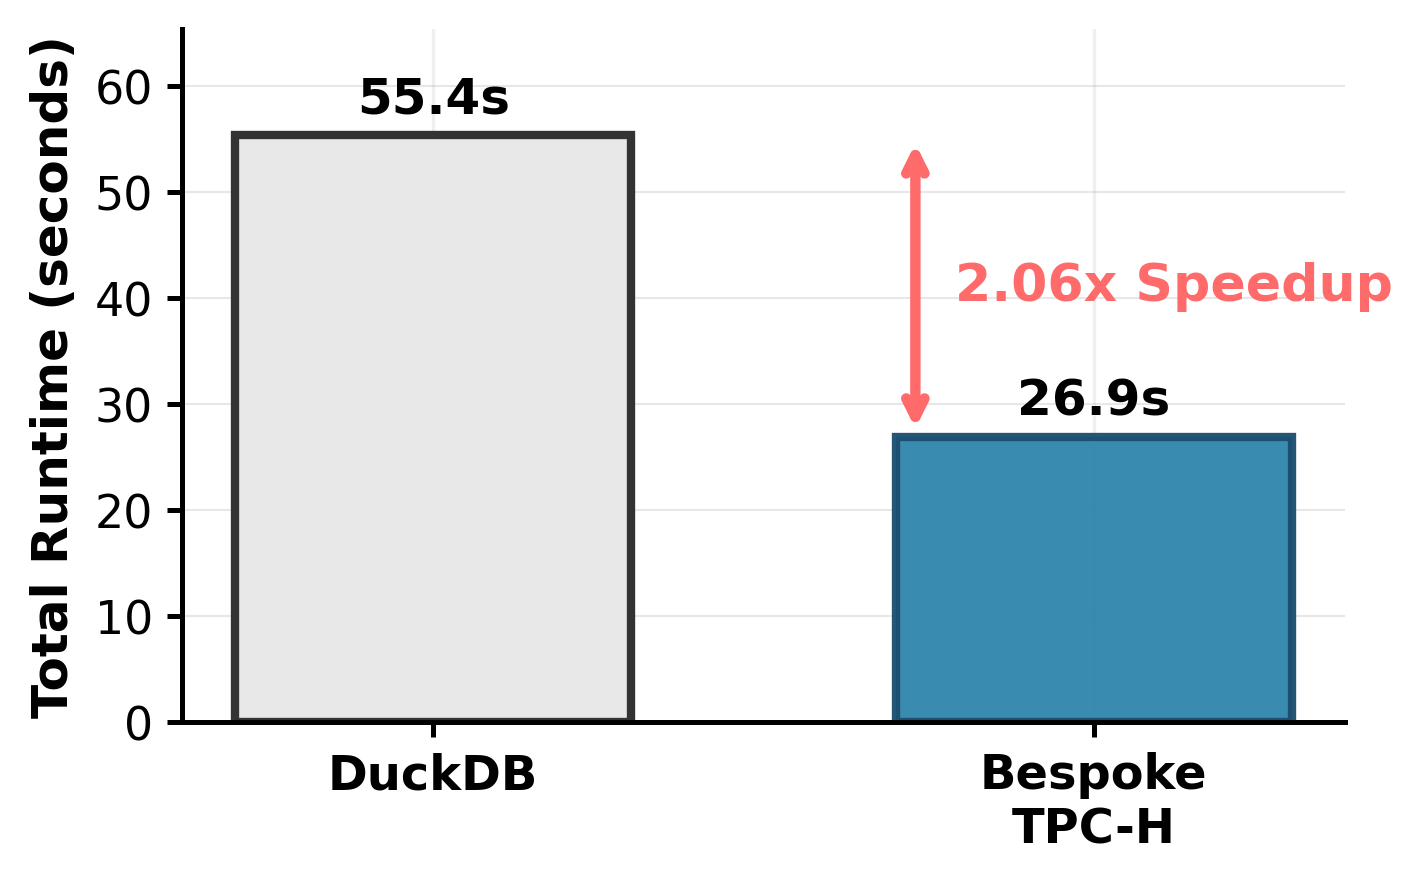


✓ Plot saved as 'journal_speedup.pdf'


In [13]:
# Toggle Umbra bars in total-runtime plots when available.

# importlib.reload(sys.modules["demo_and_analysis.plots.plot_page1"])

from demo_and_analysis.plots.plot_page1 import plot_page1

show_umbra_total_runtime = True

if is_single_benchmark:
    # Original two-bar plot for one benchmark (optionally with Umbra as third bar)
    fig, ax_main = plt.subplots(figsize=(5, 3))

    systems = ["DuckDB"]
    runtimes = [total_duckdb_time]
    bar_colors = ["#E8E8E8"]
    edge_colors = ["#333333"]
    line_widths = [2.0]

    include_umbra = show_umbra_total_runtime and (
        benchmark_metrics[active_benchmark]["total_umbra_time"] is not None
    )
    if include_umbra:
        systems.append("Umbra")
        runtimes.append(benchmark_metrics[active_benchmark]["total_umbra_time"])
        bar_colors.append("#7FB069")
        edge_colors.append("#4F6F41")
        line_widths.append(2.0)

    systems.append(f"Bespoke\n{benchmark_metrics[active_benchmark]['label']}")
    runtimes.append(total_bespoke_time)
    bar_colors.append("#2E86AB")
    edge_colors.append("#1a4d6f")
    line_widths.append(2.0)

    x_pos = np.arange(len(systems))
    bars = []
    for i in range(len(systems)):
        bars.extend(
            ax_main.bar(
                x_pos[i],
                runtimes[i],
                width=0.6,
                color=bar_colors[i],
                edgecolor=edge_colors[i],
                linewidth=line_widths[i],
                alpha=0.95 if systems[i].startswith("Bespoke") else 1.0,
            )
        )

    def annotate_bar(ax, bar, runtime_max, fmt="%.1f", fontsize=12, fontweight="bold"):
        height = bar.get_height()
        x_mid = bar.get_x() + bar.get_width() / 2
        ax.text(
            x_mid,
            height + runtime_max * 0.02,
            f"{fmt % height}s",
            ha="center",
            va="bottom",
            fontsize=fontsize,
            fontweight=fontweight,
        )

    runtime_max = max(runtimes)
    for bar in bars:
        annotate_bar(ax_main, bar, runtime_max)

    duck_idx = systems.index("DuckDB")
    bespoke_idx = len(systems) - 1
    speedup_x = x_pos[bespoke_idx] - 0.27
    ax_main.annotate(
        "",
        xy=(speedup_x, runtimes[bespoke_idx]),
        xytext=(speedup_x, runtimes[duck_idx]),
        arrowprops=dict(arrowstyle="<->", color="#FF6B6B", lw=2.5),
    )
    ax_main.text(
        speedup_x + 0.06,
        (runtimes[duck_idx] + runtimes[bespoke_idx]) / 2,
        f"{overall_speedup_total:.2f}x Speedup",
        fontsize=12.5,
        fontweight="bold",
        color="#FF6B6B",
        va="center",
        ha="left",
    )

    ax_main.set_ylabel("Total Runtime (seconds)", fontsize=12, fontweight="bold")
    ax_main.set_xticks(x_pos)
    ax_main.set_xticklabels(systems, fontsize=11.5, fontweight="bold")
    ax_main.set_ylim(0, runtime_max * 1.18)
    ax_main.grid(axis="y", alpha=0.3, linestyle="-", linewidth=0.5)
    ax_main.set_axisbelow(True)
    ax_main.spines["top"].set_visible(False)
    ax_main.spines["right"].set_visible(False)

    plt.savefig(
        "figures/journal_speedup.pdf", dpi=300, bbox_inches="tight", facecolor="white"
    )

    print("Avg. Speedup: %.2fx" % overall_speedup_mean)
    print("Median Speedup: %.2fx" % overall_speedup_median)
    if show_umbra_total_runtime and not include_umbra:
        print(
            "Note: Umbra total runtime not available for this benchmark; skipping Umbra bar."
        )

    plt.show()
    print("\n✓ Plot saved as 'journal_speedup.pdf'")

else:
    plot_page1(benchmark_metrics_by_mode, selected_benchmarks, show_umbra_total_runtime)

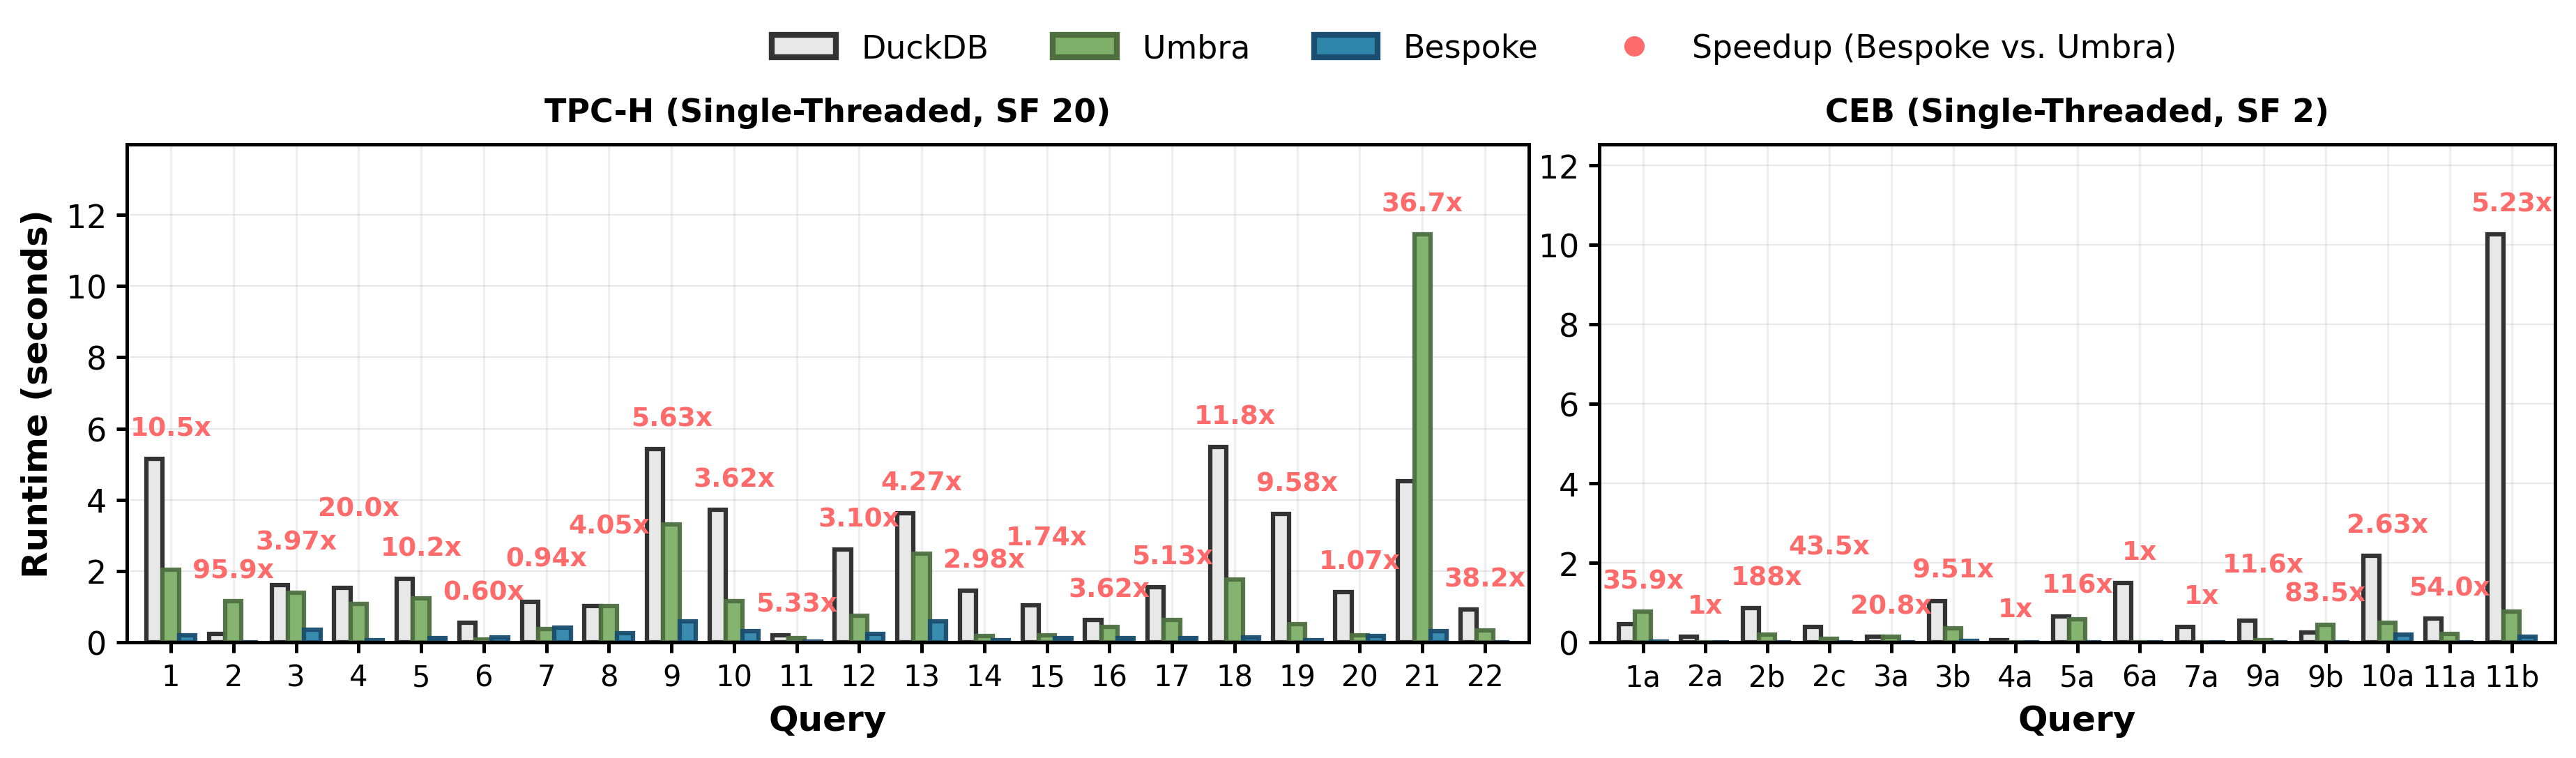


✓ Combined per-query subplot figure saved as 'journal_per_query_absolute_runtime_combined_st.pdf'


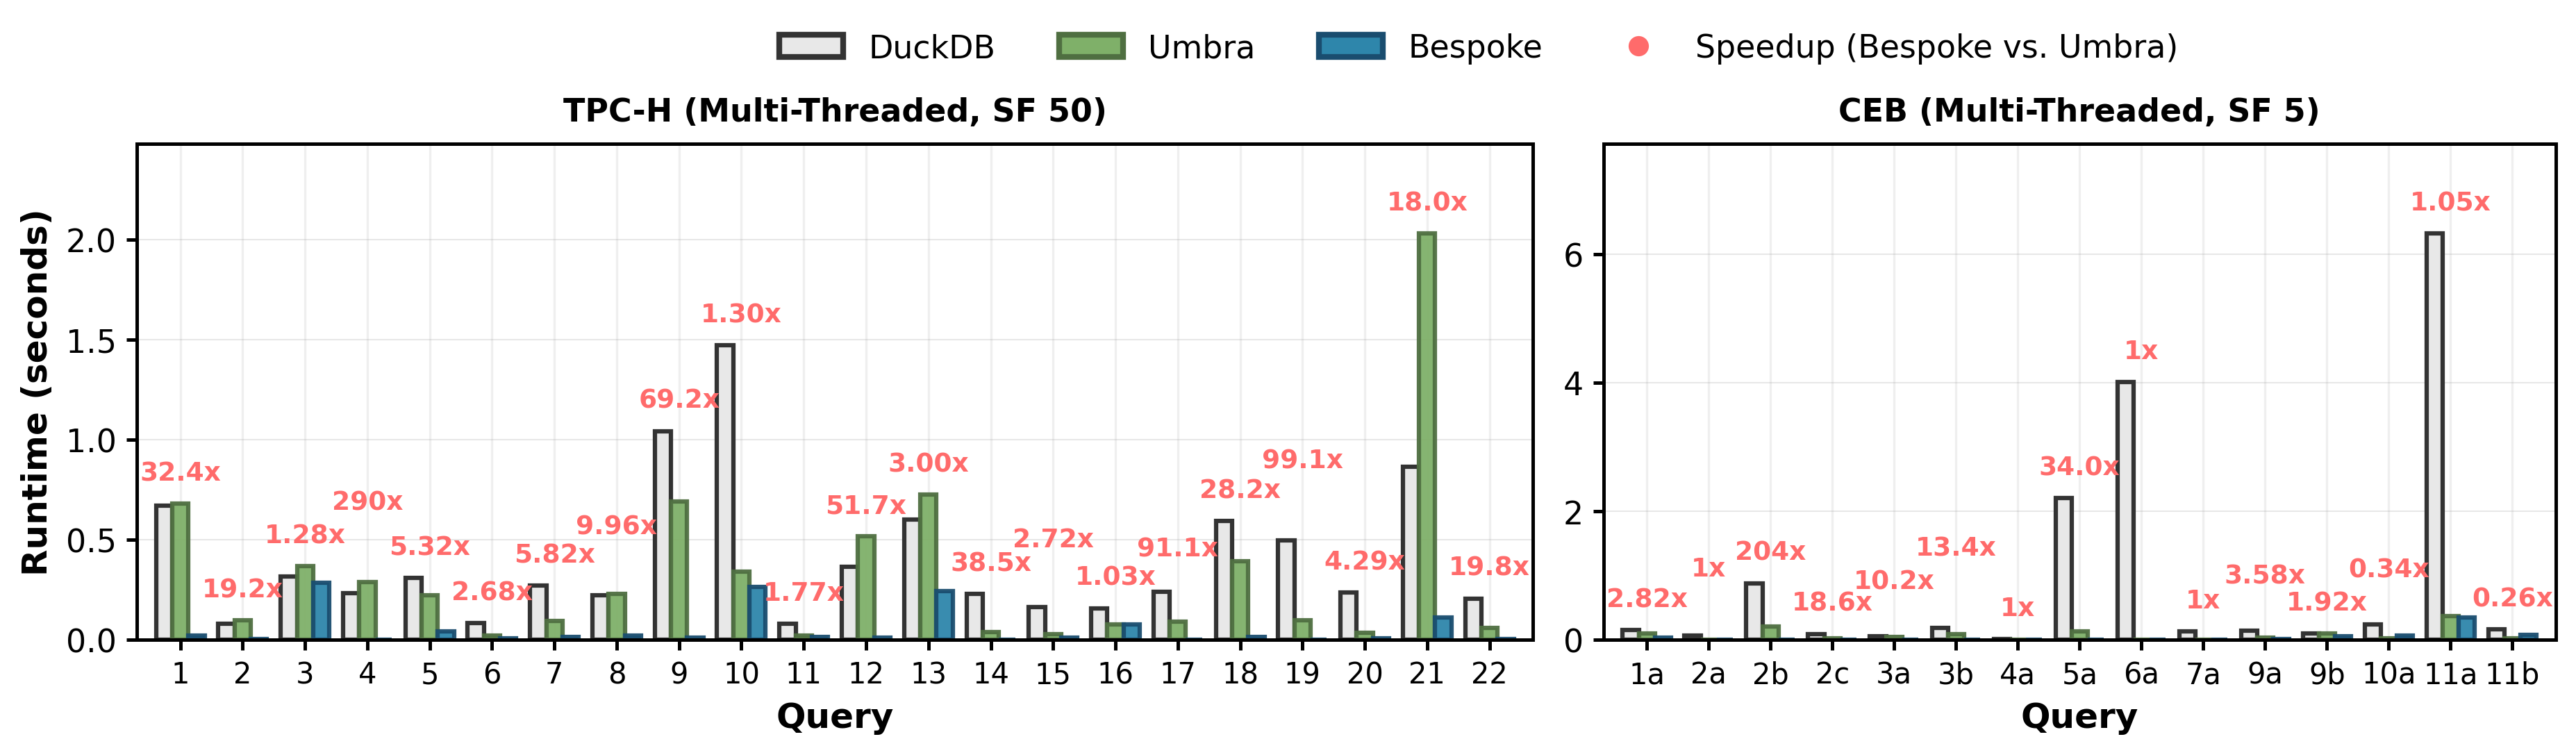


✓ Combined per-query subplot figure saved as 'journal_per_query_absolute_runtime_combined_mt.pdf'


In [71]:
# Keep combined single-row multiplots per mode (benchmarks side-by-side).
combine_per_query_subplots = True

# Toggle whether Umbra runtimes are shown as a third bar series when available.
show_umbra_runtimes = True

cmp_system = "umbra"
cmp_system_labels = {"duckdb": "DuckDB", "umbra": "Umbra"}

# Per-query absolute runtime plot (DuckDB vs Bespoke [and optional Umbra]).
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


def _query_sort_key(qid: str):
    return (0, int(qid)) if qid.isdigit() else (1, qid)


def _annotate_speedups_without_overlap(
    ax,
    x_positions,
    bar_tops,
    duck_vals,
    bespoke_vals,
    duck_x_positions=None,
    bespoke_x_positions=None,
    draw_arrow=True,
    cmp_system="duckdb",
):
    top_ref = float(np.max(bar_tops)) if len(bar_tops) else 1.0
    if top_ref <= 0:
        top_ref = 1.0

    base_offset = top_ref * 0.01
    min_vertical_gap = top_ref * 0.03
    arrow_to_text_gap = min_vertical_gap * 0.60
    arrow_min_clearance = base_offset * 2.6
    max_label_y = 0.0

    prev_x = None
    prev_y = None
    prev_lane = 0
    placed_bboxes = []
    renderer = ax.figure.canvas.get_renderer()

    for i in range(len(x_positions)):
        if cmp_system == "duckdb":
            ref_values = duck_vals
        elif cmp_system == "umbra":
            assert umbra_vals is not None, (
                "umbra_vals must be provided when cmp_system is 'umbra'"
            )
            ref_values = umbra_vals
        else:
            raise ValueError(f"Unsupported cmp_system: {cmp_system}")

        speedup = ref_values[i] / bespoke_vals[i] if bespoke_vals[i] > 0 else np.nan
        if not np.isfinite(speedup):
            continue

        if speedup > 100:
            speedup_text = f"{speedup:.0f}x"
        elif speedup > 10:
            speedup_text = f"{speedup:.1f}x"
        else:
            speedup_text = f"{speedup:.2f}x"

        base_y = float(bar_tops[i]) + base_offset
        lane = 0
        if prev_x is not None and abs(float(x_positions[i]) - prev_x) <= 1.05:
            lane = 1 - prev_lane

        min_text_y = float(bar_tops[i]) + arrow_min_clearance + arrow_to_text_gap
        y = max(base_y + lane * min_vertical_gap, min_text_y)
        if prev_x is not None and abs(float(x_positions[i]) - prev_x) <= 1.05:
            if abs(y - prev_y) < min_vertical_gap:
                y += min_vertical_gap

        if speedup_text == "0.00x":
            # this is numerically hard to measure
            speedup_text = "1x"

        text_obj = ax.text(
            x_positions[i],
            y,
            speedup_text,
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color="#FF6B6B",
        )

        ax.figure.canvas.draw()
        text_bbox = text_obj.get_window_extent(renderer=renderer).expanded(1.03, 1.12)
        nudge_attempts = 0
        while any(text_bbox.overlaps(prev_bbox) for prev_bbox in placed_bboxes):
            nudge_attempts += 1
            if nudge_attempts > 12:
                break
            y += min_vertical_gap
            text_obj.set_y(y)
            ax.figure.canvas.draw()
            text_bbox = text_obj.get_window_extent(renderer=renderer).expanded(
                1.03, 1.12
            )

        placed_bboxes.append(text_bbox)

        if draw_arrow:
            duck_x = (
                float(duck_x_positions[i])
                if duck_x_positions is not None
                else float(x_positions[i]) - 0.2
            )
            bespoke_x = (
                float(bespoke_x_positions[i])
                if bespoke_x_positions is not None
                else float(x_positions[i]) + 0.2
            )
            if abs(bespoke_x - duck_x) > 1e-9:
                span_y = y - arrow_to_text_gap
                ax.annotate(
                    "",
                    xy=(bespoke_x + 0.1, span_y),
                    xytext=(duck_x - 0.1, span_y),
                    arrowprops=dict(
                        arrowstyle="<->", color="#FF6B6B", lw=1.2, alpha=0.75
                    ),
                )

        prev_x = float(x_positions[i])
        prev_y = y
        prev_lane = lane
        max_label_y = max(max_label_y, y)

    return max_label_y


mode_order = [
    mode
    for mode in ["st", "mt"]
    if any(mode in benchmark_metrics_by_mode.get(b, {}) for b in selected_benchmarks)
]

plot_payload_by_mode = {mode: [] for mode in mode_order}
for mode in mode_order:
    for benchmark_name in selected_benchmarks:
        metrics = benchmark_metrics_by_mode.get(benchmark_name, {}).get(mode)
        if metrics is None:
            continue

        benchmark_label = metrics["label"]
        query_ids_local = metrics["query_ids"]
        duckdb_runtimes_local = metrics["duckdb_runtimes"]
        bespoke_runtimes_local = metrics["bespoke_runtimes"]
        umbra_runtimes_local = metrics["umbra_runtimes"]

        plot_query_ids = [
            qid
            for qid in query_ids_local
            if qid in duckdb_runtimes_local and qid in bespoke_runtimes_local
        ]

        if not plot_query_ids:
            print(
                f"Skipping per-query plot for {benchmark_label}/{mode}: no per-query runtime data available."
            )
            continue

        use_umbra_for_benchmark = False
        if show_umbra_runtimes:
            umbra_query_ids = [
                qid for qid in plot_query_ids if qid in umbra_runtimes_local
            ]
            if umbra_query_ids:
                if len(umbra_query_ids) < len(plot_query_ids):
                    print(
                        f"[{benchmark_label}/{mode}] Umbra available for {len(umbra_query_ids)}/{len(plot_query_ids)} queries; plotting shared subset."
                    )
                plot_query_ids = umbra_query_ids
                use_umbra_for_benchmark = True
            else:
                print(
                    f"[{benchmark_label}/{mode}] Umbra runtimes not available; plotting DuckDB vs Bespoke only."
                )

        plot_query_ids = sorted(plot_query_ids, key=_query_sort_key)
        labels = [qid.lstrip("0") for qid in plot_query_ids]
        labels = [f"{qid}" for qid in labels]

        duck_vals = np.array([duckdb_runtimes_local[qid] for qid in plot_query_ids])
        bespoke_vals = np.array([bespoke_runtimes_local[qid] for qid in plot_query_ids])
        umbra_vals = (
            np.array([umbra_runtimes_local[qid] for qid in plot_query_ids])
            if use_umbra_for_benchmark
            else None
        )

        plot_payload_by_mode[mode].append(
            {
                "benchmark_name": benchmark_name,
                "benchmark_label": benchmark_label,
                "labels": labels,
                "duck_vals": duck_vals,
                "bespoke_vals": bespoke_vals,
                "umbra_vals": umbra_vals,
                "target_sf": metrics["target_sf"],
            }
        )

any_output = False
for mode in mode_order:
    payloads = plot_payload_by_mode.get(mode, [])
    if not payloads:
        continue

    # Keep benchmarks in one row for this mode.
    query_counts = [len(p["labels"]) for p in payloads]
    width_ratios = query_counts
    per_query_width = 0.34
    fixed_width_per_subplot = 1.2
    fig_width = sum(q * per_query_width + fixed_width_per_subplot for q in query_counts)
    fig_height = 3.5

    fig, axes = plt.subplots(
        1,
        len(payloads),
        figsize=(fig_width, fig_height),
        gridspec_kw={"width_ratios": width_ratios},
    )

    if len(payloads) == 1:
        axes = [axes]

    any_umbra_plotted = False
    for idx, (ax, payload) in enumerate(zip(axes, payloads)):
        labels = payload["labels"]
        duck_vals = payload["duck_vals"]
        bespoke_vals = payload["bespoke_vals"]
        umbra_vals = payload["umbra_vals"]

        x = np.arange(len(labels))
        if umbra_vals is not None:
            any_umbra_plotted = True
            width = 0.26
            duck_x_positions = x - width
            umbra_x_positions = x
            bespoke_x_positions = x + width

            ax.bar(
                duck_x_positions,
                duck_vals,
                width=width,
                color="#E8E8E8",
                edgecolor="#333333",
                linewidth=1.5,
                alpha=1.0,
                label="DuckDB",
            )
            ax.bar(
                umbra_x_positions,
                umbra_vals,
                width=width,
                color="#7FB069",
                edgecolor="#4F6F41",
                linewidth=1.5,
                alpha=0.95,
                label="Umbra",
            )
            ax.bar(
                bespoke_x_positions,
                bespoke_vals,
                width=width,
                color="#2E86AB",
                edgecolor="#1a4d6f",
                linewidth=1.5,
                alpha=0.95,
                label=f"Bespoke {payload['benchmark_label']}",
            )
            bar_tops = np.maximum(np.maximum(duck_vals, bespoke_vals), umbra_vals)
        else:
            width = 0.38
            duck_x_positions = x - width / 2
            bespoke_x_positions = x + width / 2

            ax.bar(
                duck_x_positions,
                duck_vals,
                width=width,
                color="#E8E8E8",
                edgecolor="#333333",
                linewidth=2.0,
                alpha=1.0,
                label="DuckDB",
            )
            ax.bar(
                bespoke_x_positions,
                bespoke_vals,
                width=width,
                color="#2E86AB",
                edgecolor="#1a4d6f",
                linewidth=2.0,
                alpha=0.95,
                label=f"Bespoke {payload['benchmark_label']}",
            )
            bar_tops = np.maximum(duck_vals, bespoke_vals)

        max_label_y = _annotate_speedups_without_overlap(
            ax,
            x,
            bar_tops,
            duck_vals,
            bespoke_vals,
            duck_x_positions=duck_x_positions,
            bespoke_x_positions=bespoke_x_positions,
            draw_arrow=False,
            cmp_system=cmp_system,
        )

        ax.set_xlim(-0.7, len(labels) - 0.3)
        if idx == 0:
            ax.set_ylabel("Runtime (seconds)", fontsize=12, fontweight="bold")
        ax.set_xlabel("Query", fontsize=12, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=10)

        top_ref = float(bar_tops.max()) if len(bar_tops) else 1.0
        if top_ref <= 0:
            top_ref = 1.0
        ax.set_ylim(0, max(top_ref * 1.22, max_label_y + top_ref * 0.12))
        ax.grid(axis="y", alpha=0.3, linestyle="-", linewidth=0.5)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(True)
        ax.spines["right"].set_visible(True)

        mode_lookup = {"st": "Single-Threaded", "mt": "Multi-Threaded"}

        ax.set_title(
            f"{payload['benchmark_label']} ({mode_lookup[mode]}, SF {payload['target_sf']})",
            fontsize=11,
            fontweight="bold",
            pad=8,
        )

    legend_handles = [
        Patch(
            facecolor="#E8E8E8",
            edgecolor="#333333",
            linewidth=2.0,
            label="DuckDB",
        )
    ]
    if any_umbra_plotted:
        legend_handles.append(
            Patch(
                facecolor="#7FB069",
                edgecolor="#4F6F41",
                linewidth=2.0,
                label="Umbra",
            )
        )
    legend_handles.append(
        Patch(
            facecolor="#2E86AB",
            edgecolor="#1a4d6f",
            linewidth=2.0,
            label="Bespoke",
        )
    )
    legend_handles.append(
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="None",
            color="#FF6B6B",
            markersize=6,
            label=f"Speedup (Bespoke vs. {cmp_system_labels[cmp_system]})",
        )
    )

    fig.legend(
        handles=legend_handles,
        frameon=False,
        fontsize=11,
        loc="lower center",
        ncols=len(legend_handles),
        bbox_to_anchor=(0.555, 0.95),
    )

    fig.subplots_adjust(wspace=0.06, bottom=0.2)

    out_name = f"journal_per_query_absolute_runtime_combined_{mode}.pdf"
    out_path = f"figures/{out_name}"
    plt.savefig(
        out_path,
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.005,
        facecolor="white",
    )

    plt.show()
    print(f"\n✓ Combined per-query subplot figure saved as '{out_name}'")
    any_output = True

if not any_output:
    print("No per-query runtime data available for plotting.")